# Intergenic Region Sequence Length Distribution Analysis

This notebook analyzes and visualizes the length distributions of sequences from:
- Upstream intergenic regions
- Downstream intergenic regions
- CDS sequences

across ~300 genomes in a gene family.

In [12]:
# Import required libraries
from Bio import SeqIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

## 1. Load FASTA Files

Update the file paths below to point to your FASTA files.

In [13]:
# Define file paths - UPDATE THESE PATHS
upstream_file = "/Users/daniel/Library/Mobile Documents/com~apple~CloudDocs/workspace/DarwinsRNAHunt/results/domain_flanking_upstream.fasta"
downstream_file = "/Users/daniel/Library/Mobile Documents/com~apple~CloudDocs/workspace/DarwinsRNAHunt/results/domain_flanking_downstream.fasta"
cds_file = "/Users/daniel/Library/Mobile Documents/com~apple~CloudDocs/workspace/DarwinsRNAHunt/results/domain_flanking_cds.fasta"

# Function to read FASTA and extract sequence lengths
def get_sequence_lengths(fasta_file):
    """
    Read a FASTA file and return a list of sequence lengths.
    
    Parameters:
    -----------
    fasta_file : str
        Path to the FASTA file
    
    Returns:
    --------
    list : List of sequence lengths
    """
    lengths = []
    with open(fasta_file, 'r') as handle:
        for record in SeqIO.parse(handle, 'fasta'):
            lengths.append(len(record.seq))
    return lengths

# Load sequence lengths from all files
print("Loading FASTA files...")
upstream_lengths = get_sequence_lengths(upstream_file)
downstream_lengths = get_sequence_lengths(downstream_file)
cds_lengths = get_sequence_lengths(cds_file)

print(f"✓ Upstream sequences: {len(upstream_lengths)}")
print(f"✓ Downstream sequences: {len(downstream_lengths)}")
print(f"✓ CDS sequences: {len(cds_lengths)}")

Loading FASTA files...
✓ Upstream sequences: 348
✓ Downstream sequences: 348
✓ CDS sequences: 348


## 2. Summary Statistics

In [14]:
# Create a summary statistics table
def calculate_stats(lengths, name):
    """
    Calculate summary statistics for sequence lengths.
    """
    return {
        'Region': name,
        'Count': len(lengths),
        'Mean': np.mean(lengths),
        'Median': np.median(lengths),
        'Std Dev': np.std(lengths),
        'Min': np.min(lengths),
        'Max': np.max(lengths),
        'Q25': np.percentile(lengths, 25),
        'Q75': np.percentile(lengths, 75)
    }

# Calculate statistics for all datasets
stats_data = [
    calculate_stats(upstream_lengths, 'Upstream'),
    calculate_stats(downstream_lengths, 'Downstream'),
    calculate_stats(cds_lengths, 'CDS')
]

stats_df = pd.DataFrame(stats_data)
stats_df = stats_df.round(2)

print("\nSummary Statistics:")
print("=" * 80)
display(stats_df)


Summary Statistics:


,Region,Count,Mean,Median,Std Dev,Min,Max,Q25,Q75
0,Upstream,348,100.94,33.5,218.13,0,2770,5.00,119.0
1,Downstream,348,149.56,57.5,355.03,0,4941,16.75,121.5
2,CDS,348,483.22,423.0,244.19,234,3303,420.00,426.0


## 3. Visualizations

### 3.1 Combined Histogram

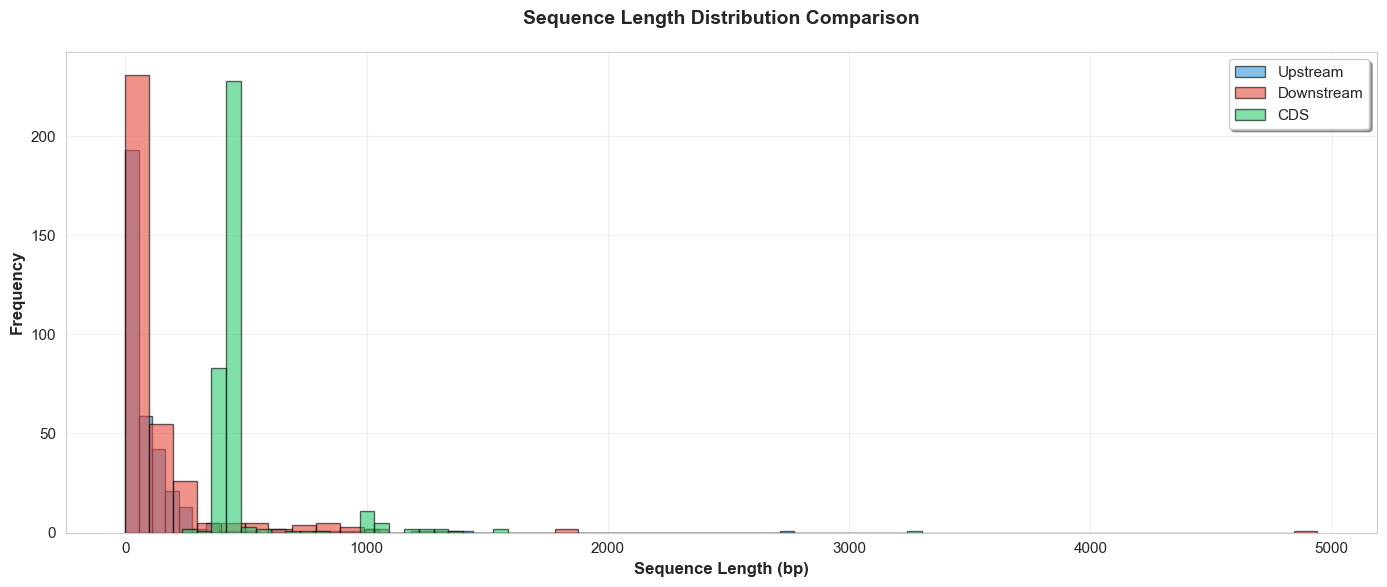

In [4]:
# Create histogram with all three distributions
fig, ax = plt.subplots(figsize=(14, 6))

# Plot histograms
ax.hist(upstream_lengths, bins=50, alpha=0.6, label='Upstream', color='#3498db', edgecolor='black')
ax.hist(downstream_lengths, bins=50, alpha=0.6, label='Downstream', color='#e74c3c', edgecolor='black')
ax.hist(cds_lengths, bins=50, alpha=0.6, label='CDS', color='#2ecc71', edgecolor='black')

ax.set_xlabel('Sequence Length (bp)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Sequence Length Distribution Comparison', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, frameon=True, shadow=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 Separate Histograms

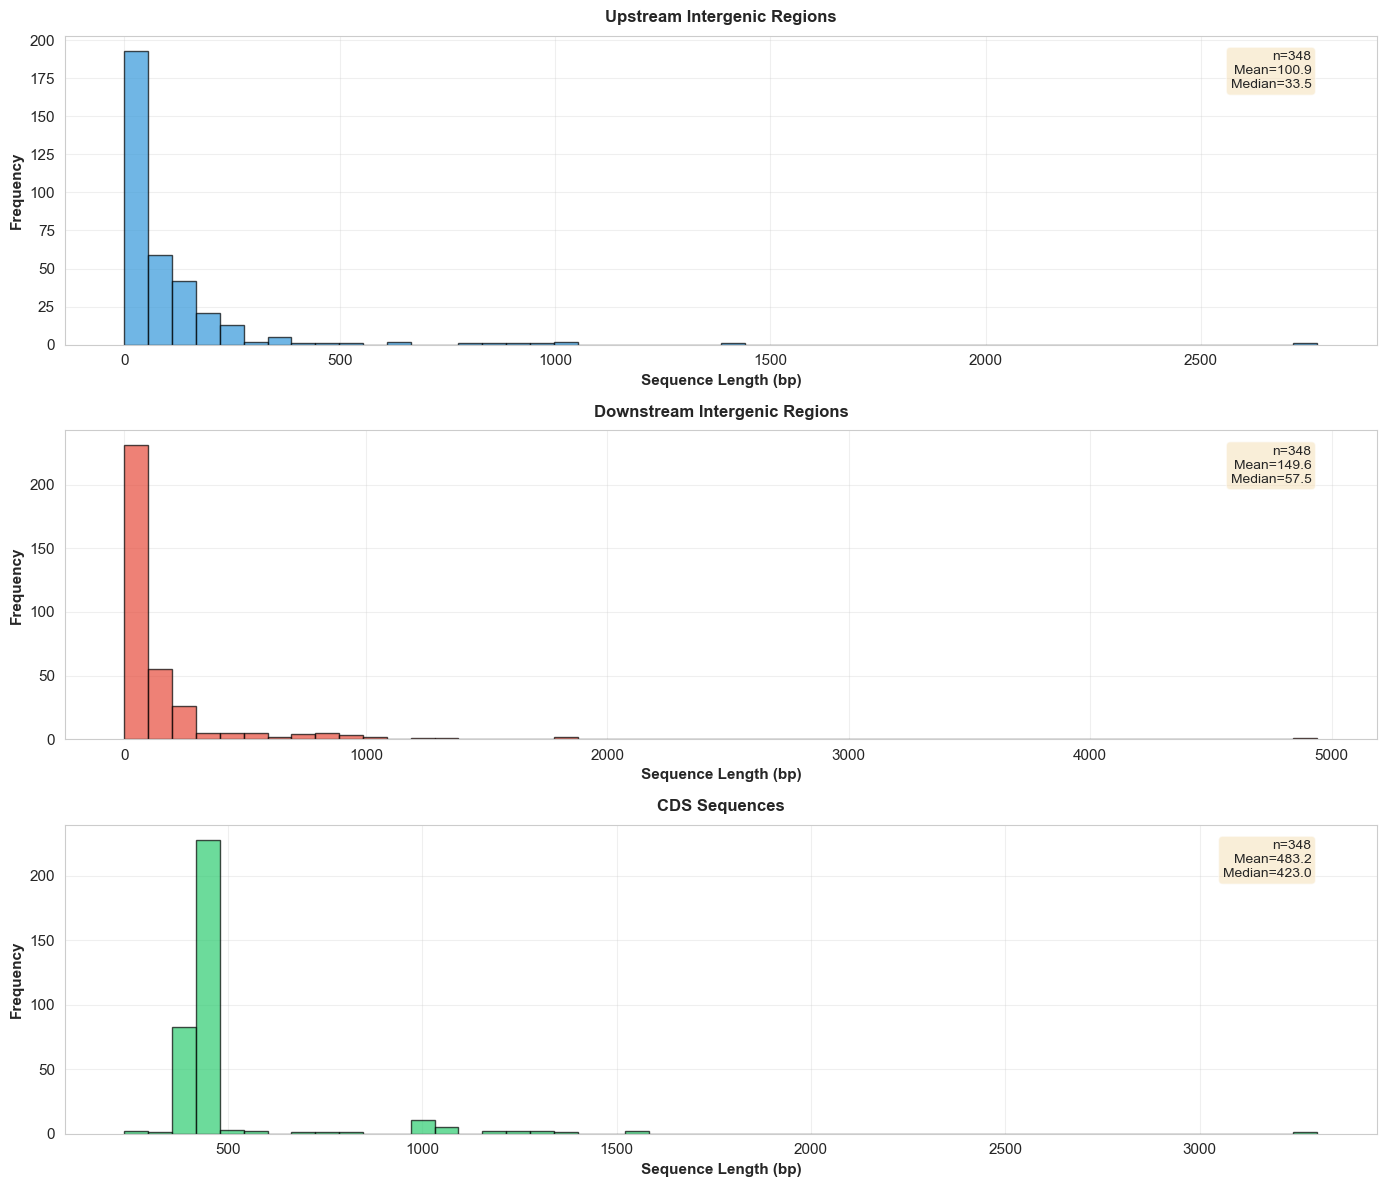

In [5]:
# Create separate subplots for each region
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

datasets = [
    (upstream_lengths, 'Upstream Intergenic Regions', '#3498db'),
    (downstream_lengths, 'Downstream Intergenic Regions', '#e74c3c'),
    (cds_lengths, 'CDS Sequences', '#2ecc71')
]

for ax, (data, title, color) in zip(axes, datasets):
    ax.hist(data, bins=50, alpha=0.7, color=color, edgecolor='black')
    ax.set_xlabel('Sequence Length (bp)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.3)
    
    # Add statistics text box
    stats_text = f"n={len(data)}\nMean={np.mean(data):.1f}\nMedian={np.median(data):.1f}"
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            fontsize=10)

plt.tight_layout()
plt.show()

### 3.3 Box Plots

/var/folders/nf/rkh43rnd7292vf6qk8ps_5hc0000gn/T/ipykernel_68015/3359738251.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_boxplot, labels=labels, patch_artist=True,


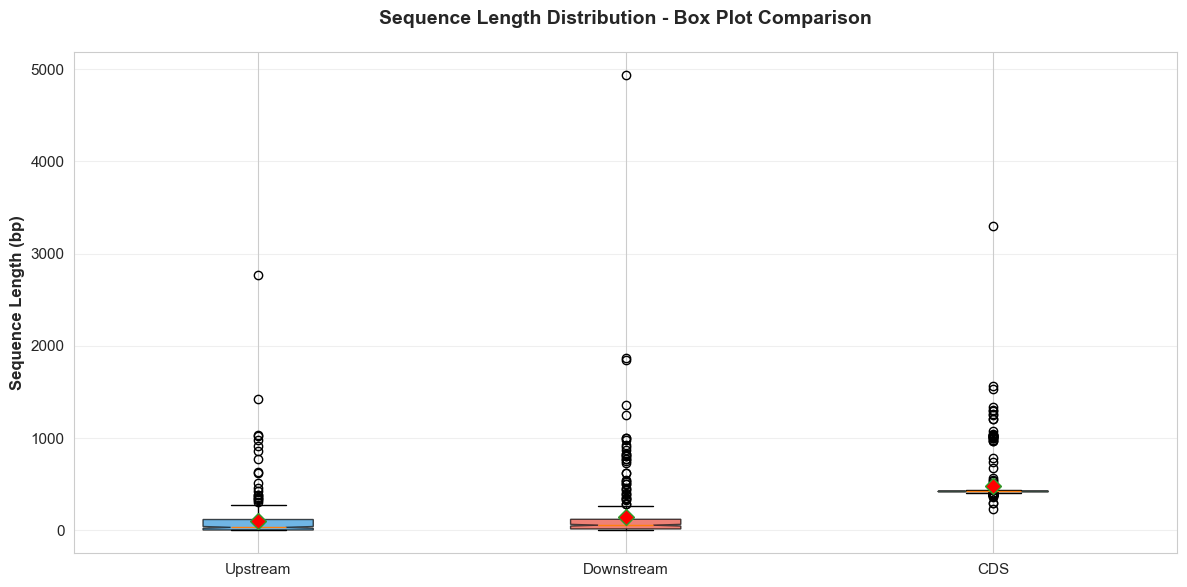

In [6]:
# Create boxplot comparison
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for boxplot
data_for_boxplot = [upstream_lengths, downstream_lengths, cds_lengths]
labels = ['Upstream', 'Downstream', 'CDS']
colors = ['#3498db', '#e74c3c', '#2ecc71']

bp = ax.boxplot(data_for_boxplot, labels=labels, patch_artist=True,
                notch=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Sequence Length (bp)', fontsize=12, fontweight='bold')
ax.set_title('Sequence Length Distribution - Box Plot Comparison', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 3.4 Violin Plots

/var/folders/nf/rkh43rnd7292vf6qk8ps_5hc0000gn/T/ipykernel_68015/1458040350.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='Region', y='Length', palette=colors, ax=ax)


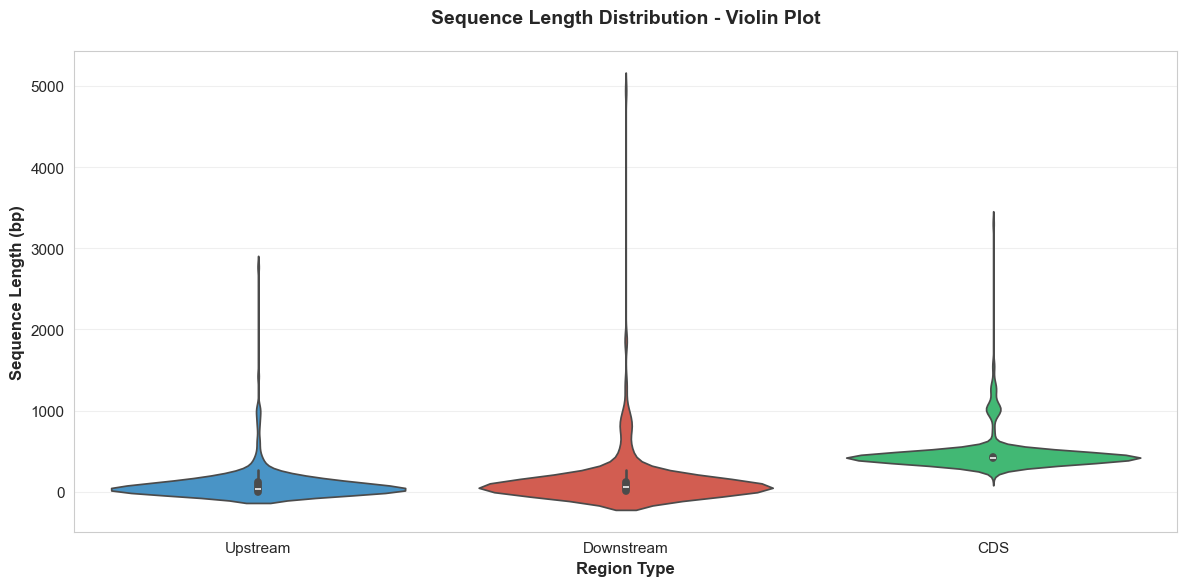

In [7]:
# Create violin plot
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data in long format for seaborn
df_plot = pd.DataFrame({
    'Length': upstream_lengths + downstream_lengths + cds_lengths,
    'Region': ['Upstream']*len(upstream_lengths) + 
              ['Downstream']*len(downstream_lengths) + 
              ['CDS']*len(cds_lengths)
})

sns.violinplot(data=df_plot, x='Region', y='Length', palette=colors, ax=ax)

ax.set_ylabel('Sequence Length (bp)', fontsize=12, fontweight='bold')
ax.set_xlabel('Region Type', fontsize=12, fontweight='bold')
ax.set_title('Sequence Length Distribution - Violin Plot', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 3.5 Cumulative Distribution

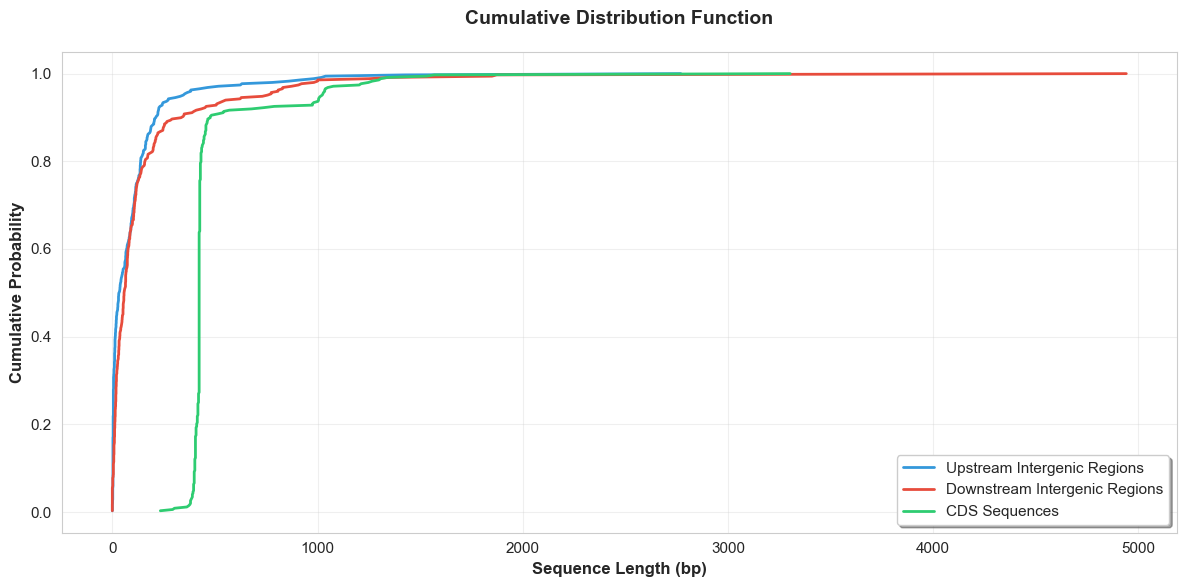

In [8]:
# Create cumulative distribution plot
fig, ax = plt.subplots(figsize=(12, 6))

for data, label, color in datasets:
    sorted_data = np.sort(data)
    y = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, y, label=label, linewidth=2, color=color)

ax.set_xlabel('Sequence Length (bp)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax.set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, frameon=True, shadow=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.6 Density Plot

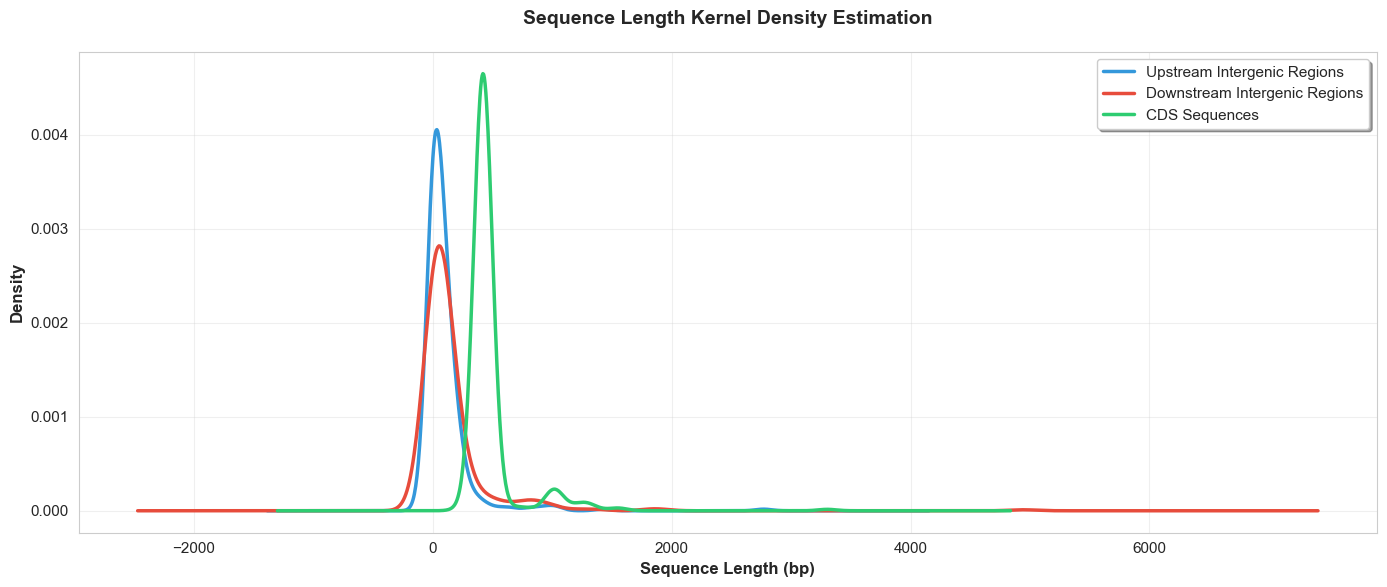

In [9]:
# Create density plot
fig, ax = plt.subplots(figsize=(14, 6))

for data, label, color in datasets:
    df_plot[df_plot['Region'] == label.split()[0]]['Length'].plot.kde(
        ax=ax, label=label, linewidth=2.5, color=color
    )

ax.set_xlabel('Sequence Length (bp)', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Sequence Length Kernel Density Estimation', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, frameon=True, shadow=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Statistical Tests

Perform statistical tests to compare distributions.

In [10]:
# Kruskal-Wallis H-test (non-parametric alternative to ANOVA)
h_stat, p_value = stats.kruskal(upstream_lengths, downstream_lengths, cds_lengths)

print("Kruskal-Wallis H-test")
print("=" * 50)
print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Significant difference: {'Yes' if p_value < 0.05 else 'No'} (α=0.05)")
print()

# Pairwise Mann-Whitney U tests
print("\nPairwise Mann-Whitney U Tests")
print("=" * 50)

comparisons = [
    ('Upstream', 'Downstream', upstream_lengths, downstream_lengths),
    ('Upstream', 'CDS', upstream_lengths, cds_lengths),
    ('Downstream', 'CDS', downstream_lengths, cds_lengths)
]

for name1, name2, data1, data2 in comparisons:
    u_stat, p_val = stats.mannwhitneyu(data1, data2, alternative='two-sided')
    print(f"{name1} vs {name2}:")
    print(f"  U-statistic: {u_stat:.4f}")
    print(f"  P-value: {p_val:.4e}")
    print(f"  Significant: {'Yes' if p_val < 0.05 else 'No'} (α=0.05)")
    print()

Kruskal-Wallis H-test
H-statistic: 556.4570
P-value: 1.4686e-121
Significant difference: Yes (α=0.05)


Pairwise Mann-Whitney U Tests
Upstream vs Downstream:
  U-statistic: 51903.0000
  P-value: 1.1081e-03
  Significant: Yes (α=0.05)

Upstream vs CDS:
  U-statistic: 4194.0000
  P-value: 7.2190e-101
  Significant: Yes (α=0.05)

Downstream vs CDS:
  U-statistic: 9471.0000
  P-value: 3.4661e-83
  Significant: Yes (α=0.05)



## 5. Export Results

In [11]:
# Save summary statistics to CSV
stats_df.to_csv('sequence_length_statistics.csv', index=False)
print("✓ Summary statistics saved to 'sequence_length_statistics.csv'")

# Save individual length data
length_data = pd.DataFrame({
    'Upstream': pd.Series(upstream_lengths),
    'Downstream': pd.Series(downstream_lengths),
    'CDS': pd.Series(cds_lengths)
})
length_data.to_csv('sequence_lengths_raw.csv', index=False)
print("✓ Raw sequence lengths saved to 'sequence_lengths_raw.csv'")

✓ Summary statistics saved to 'sequence_length_statistics.csv'
✓ Raw sequence lengths saved to 'sequence_lengths_raw.csv'


## Summary

This notebook provides comprehensive visualizations of sequence length distributions for:
- **Upstream intergenic regions**
- **Downstream intergenic regions**
- **CDS sequences**

The analysis includes:
- Summary statistics
- Multiple visualization types (histograms, box plots, violin plots, density plots)
- Statistical tests for comparing distributions
- Export of results to CSV files